In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("heart.csv")

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
#EDA
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [6]:
df.shape

(918, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

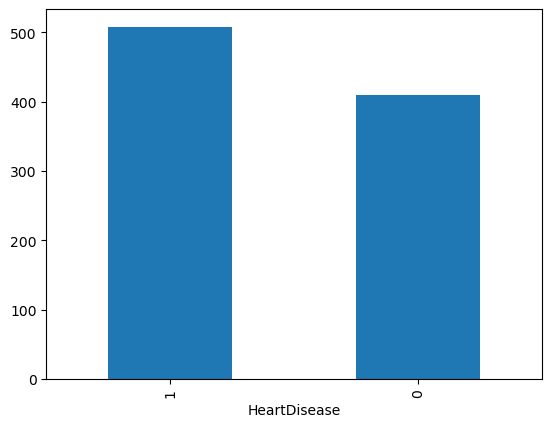

In [10]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

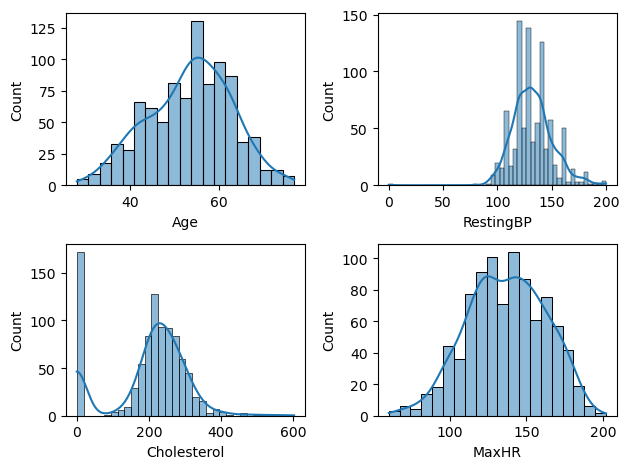

In [12]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [13]:
ch_mean = df.loc[df['Cholesterol'] !=0 ,'Cholesterol'].mean()       

In [14]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [15]:
resting_bp_mean=df.loc[df['RestingBP'] !=0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,ch_mean)   
df['RestingBP'] = df['RestingBP'].round(2)

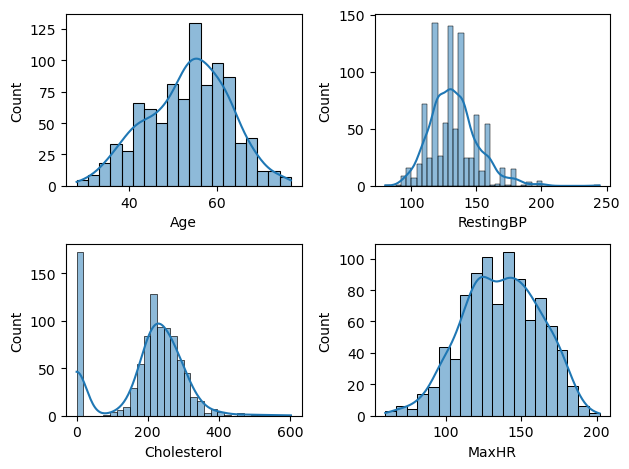

In [16]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [17]:
pip install sheryanalysis==0.1.0

Note: you may need to restart the kernel to use updated packages.


In [18]:
import sheryanalysis as sh
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': <StringDtype(na_value=nan)>,
  'ChestPainType': <StringDtype(na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('int64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',
 

<Axes: xlabel='Sex', ylabel='count'>

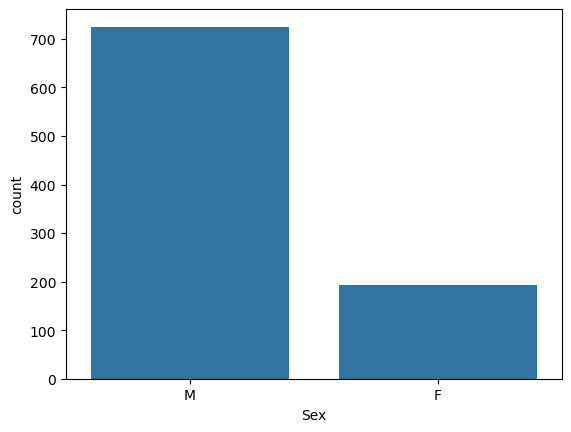

In [19]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

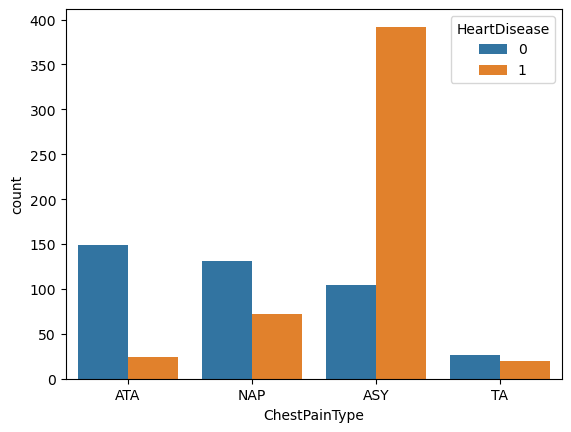

In [20]:
sns.countplot(x =df['ChestPainType'],hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

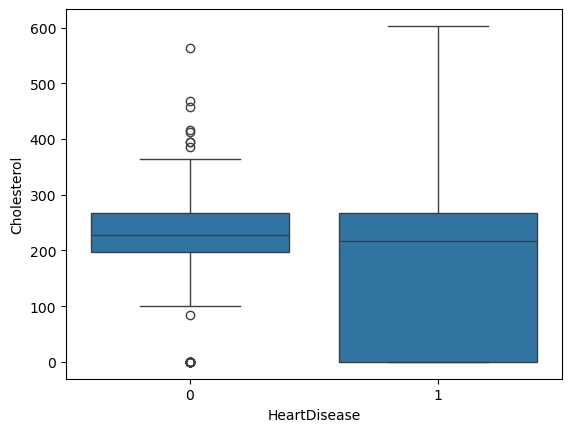

In [21]:
sns.boxplot(x = "HeartDisease",y='Cholesterol',data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

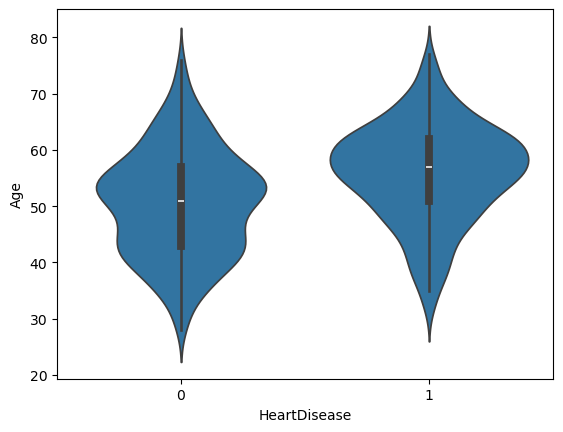

In [22]:
sns.violinplot(x ='HeartDisease',y = "Age",data =df)

<Axes: >

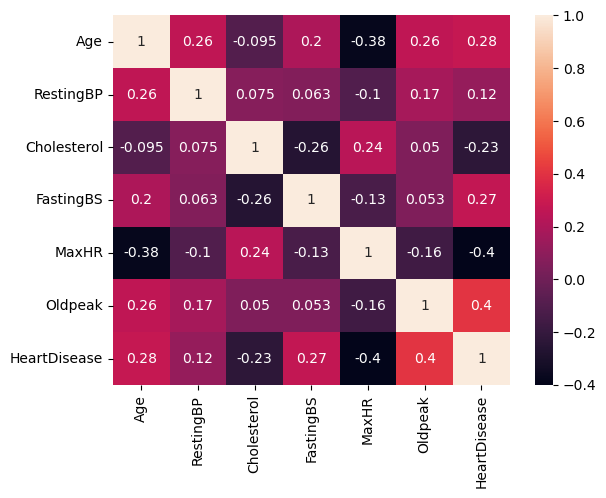

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot = True)

# Data preprocessing And Cleaning

In [24]:
df_encode = pd.get_dummies(df,drop_first = True)

In [25]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [26]:
df_encode = df_encode.astype(int)

In [27]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
numeric_col = ['Age',"RestingBP",'Cholesterol','MaxHR',"Oldpeak"]
scaler = StandardScaler()
df_encode[numeric_col] = scaler.fit_transform(df_encode[numeric_col])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.825070,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.489614,-0.171961,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.770188,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.290847,0.139040,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.944720,-0.034755,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [31]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score,classification_report
from sklearn.linear_model import LogisticRegressionCV
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [49]:
X = df_encode.drop('HeartDisease',axis = 1)
y = df_encode['HeartDisease']


In [50]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [51]:
scaler = StandardScaler()
x_train_scl = scaler.fit_transform(x_train)
x_test_scl = scaler.fit_transform(x_test)

In [53]:
models = {
    'logistic regression':LogisticRegressionCV(),
    'KNN' : KNeighborsClassifier(),
    'Naive Byeas' : GaussianNB(),
    "decision tree" : DecisionTreeClassifier(),
    "svm": SVC()
}

In [63]:
result = []

In [64]:
for name,model in models.items():
    model.fit(x_train_scl,y_train)
    y_pre = model.predict(x_test_scl)
    acc = accuracy_score(y_test,y_pre)
    f1 = f1_score(y_test,y_pre)
    result.append({
        'model' :name,
        'accuracy':round(acc,4),
        "f1 score" :round(f1,4)
    })

In [65]:
result

[{'model': 'logistic regression', 'accuracy': 0.8587, 'f1 score': 0.875},
 {'model': 'KNN', 'accuracy': 0.8533, 'f1 score': 0.8696},
 {'model': 'Naive Byeas', 'accuracy': 0.8696, 'f1 score': 0.8857},
 {'model': 'decision tree', 'accuracy': 0.7663, 'f1 score': 0.8018},
 {'model': 'svm', 'accuracy': 0.8804, 'f1 score': 0.8972}]

In [69]:
import joblib
joblib.dump(models['svm'],'svm_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'columns.pkl')

['columns.pkl']

In [68]:
X

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.399826,0.825070,0,1.382928,-0.727592,1,1,0,0,1,0,0,0,1
1,-0.478484,1.489614,-0.171961,0,0.754157,0.282891,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.145068,0.770188,0,-1.525138,-0.727592,1,1,0,0,0,1,0,0,1
3,-0.584556,0.290847,0.139040,0,-1.132156,0.282891,0,0,0,0,1,0,1,1,0
4,0.051881,0.944720,-0.034755,0,-0.581981,-0.727592,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.234855,0.596393,0,-0.188999,0.282891,1,0,0,1,1,0,0,1,0
914,1.536902,0.617784,-0.053049,1,0.164684,2.303858,1,0,0,0,1,0,0,1,0
915,0.370100,-0.145068,-0.620168,0,-0.857069,0.282891,1,0,0,0,1,0,1,1,0
916,0.370100,-0.145068,0.340275,0,1.461525,-0.727592,0,1,0,0,0,0,0,1,0
